In [67]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import sys
from pathlib import Path
import xarray as xr
import cfgrib
import cartopy.crs as ccrs  # Projeções de mapas.
import cartopy.feature as cfeature  # Elementos geográficos.
from matplotlib.tri import Triangulation

#Import local libraries
import aux

In [68]:
init='2025120100'
year='2025'
month='12'
base_dir='/p/projetos/monan_atm/madeleine.gacita/global_data/'
exps_data={
    "CTRL": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/CTRL/"},
    "teste_10deep": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/teste_10deep/"},
    "teste_2deep": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/teste_2deep/"},
    # "teste_2mid": {
    #     "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/teste_2mid/"},
    "teste_2shallow": {
        "dir": f"/p/projetos/monan_atm/madeleine.gacita/scripts_CD-CT/dataout/teste_2shallow/"},

}
extents={"SA":{
            "extent":[-90, -30, -40, 10],
            "label":"South America"},
        "Global":{
            "extent":[-180, 180, -90, 90],
            "label":"Global"},
        }


In [ ]:
var_dict={
    "ISR": {
        "era5_name" : "ssrd",
        "era5_longname" :"surface_solar_radiation_downwards",
        "ceres_name" : "init_all_sfc_sw_dn", 
        "monan_name" : "swdnb",
        "unit" : "W m^{-2}",
        "label" : "Surface shortwave radiation downwards",
        "convert_to_flux": "yes",
        "vmin" : 0,
        "vmax" : 1300,
        "vmin_diff" : -200,
        "vmax_diff" : 200,
    },
    "ISRC": {
        "era5_name" : "ssrdc",
        "era5_longname" :"surface_solar_radiation_downward_clear_sky",
        "ceres_name" : "init_clr_sfc_sw_dn", 
        "monan_name" : "swdnbc",
        "unit" : "W m^{-2}",
        "label" : "Surface shortwave radiation downwards (clear sky)",
        "convert_to_flux": "yes",
        "vmin" : 0,
        "vmax" : 1300,
        "vmin_diff" : -200,
        "vmax_diff" : 200,
    },
    "OLR": {
        "era5_name": "ttr",
        "era5_longname" :"top_net_thermal_radiation",
        "ceres_name" : "init_all_toa_lw_up", 
        "monan_name" : "lwupt",
        "unit" : "W m^{-2}",
        "label" : "TOA Outgoing longwave radiation",
        "convert_to_flux": "yes",
        "vmin" : -400,
        "vmax" : 0
    },
    "OLRC": {
        "era5_name" : "ttrc",
        "era5_longname" : "top_net_thermal_radiation_clear_sky",
        "ceres_name" : "init_clr_toa_lw_up", 
        "monan_name" : "lwuptc",
        "unit" : "W m^{-2}",
        "label" : "TOA Outgoing longwave radiation (clear sky)",
        "convert_to_flux": "yes",
        "vmin" : -400,
        "vmax" : 0,
        "vmin_diff" : -50,
        "vmax_diff" : 50
    },
    "TISR": {
        "era5_name" : "tisr",
        "era5_longname" : "toa_incident_solar_radiation",
        "ceres_name" : "toa_sw_insol", 
        "monan_name" : "swdnt",
        "unit" : "W m^{-2}",
        "label" : "TOA incident short-wave (solar) radiation",
        "convert_to_flux": "yes",
        "vmin" : 0,
        "vmax" : 1300,
        "vmin_diff" : -50,
        "vmax_diff" : 50
    },
    "PC": {
        "era5_name" : "tclw",
        "era5_longname" :"total_column_cloud_liquid_water",
        "ceres_name" : "obs_cld_lwp", 
        "monan_name" : "precipcloud",
        "unit" : "kg*m^{-2}",
        "label" : "Total column cloud liquid water",
        "vmin" : 0.05,
        "vmax" : 1,
        "vmin_diff" : -2,
        "vmax_diff" : 2,
        "convert_to_flux": "no",
    },
    "PI": {
        "era5_name": "tciw",
        "era5_longname" :"total_column_cloud_ice_water",
        "ceres_name" : "obs_cld_iwp", 
        "monan_name" : "precipice",
        "unit" : "kg*m^{-2}",
        "label" : "Total column cloud ice water",
        "vmin" : 0.05,
        "vmax" : 1,
        "vmin_diff" : -2,
        "vmax_diff" : 2,
        "convert_to_flux": "no",
    },
     "RAINC": {
        "era5_name" : "cp",
        "era5_longname" : "convective_precipitation",
        "ceres_name" : "", 
        "monan_name" : "rainc",
        "unit" : "kg*m^{-2}",
        "label" : "Convective precipitation",
        "vmin" : 0.5,
        "vmax" : 15,
        "vmin_diff" : -5,
        "vmax_diff" : 5,
        "convert_to_flux": "no",
    }, 
     "RAINNC": {
        "era5_name" : "tp",
        "era5_longname" : "total_precipitation",
        "ceres_name" : "", 
        "monan_name" : "rainnc",
        "unit" : "kg*m^{-2}",
        "label" : "Grid-scale precipitation",
        "vmin" : 0.5,
        "vmax" : 15,
        "vmin_diff" : -5,
        "vmax_diff" : 5,
        "convert_to_flux": "no",
    },  
    "CAPE": {
        "era5_name" : "cape",
        "era5_longname" : "convective_available_potential_energy",
        "ceres_name" : "cape", 
        "monan_name" : "cape",
        "unit" : "J kg^{-1}",
        "label" : "Convective available potential energy",
        "convert_to_flux": "no",
        "vmin" : 0,
        "vmax" : 2000
    },
    "CIN": {
        "era5_name" : "cin",
        "era5_longname" : "convective_inhibition",
        "ceres_name" : "cin", 
        "monan_name" : "cin",
        "unit" : "J kg^{-1}",
        "label" : "Convective inhibition",
        "convert_to_flux": "no",
        "vmin" : 0,
        "vmax" : 300
    }
}

surf_flux_dict={
    "HF": {
        "era5_name" : "sshf",
        "era5_longname" : "surface_sensible_heat_flux",
        "monan_name" : "hfx", 
        "unit" : "W/m**2",
        "label" : "Sensible heat flux"
    },
    "LF": {
        "era5_name": "sslf",
        "era5_longname":"surface_latent_heat_flux",
        "monan_name": "lf", 
        "unit": "W m^{-2}",
        "label": "Latent heat flux"
    }
}

profile_vars_dict={
    "ISR": {
        "monan_name" : "ssrd",
        "ceres_name" : "adj_all_sw_dn",
        "unit" : "W m^{-2}",
        "label" : "Incoming shortwave radiation"
    },
    "OSR": {
        "monan_name" : "ssrd",
        "ceres_name" : "adj_all_sw_up", 
        "unit" : "W m^{-2}",
        "label" : "Outgoing shortwave radiation"
    },
    "ILR": {
        "monan_name" : "ttrc",
        "ceres_name" : "adj_all_lw_dn", 
        "unit" : "W m^{-2}",
        "label" : "Incoming longwave radiation"
    },
    "OLR": {
        "monan_name" : "ttr",
        "ceres_name" : "adj_all_lw_up", 
        "unit" : "W m^{-2}",
        "label" : "Outgoing longwave radiation"
    }    
}

In [70]:
def apply_lon_lat_conventions(ds):
    # Renames
    if "lon" in ds.dims:
        ds = ds.rename({"lon": "longitude"})
    if "lat" in ds.dims:
        ds = ds.rename({"lat": "latitude"})
 
    # Flip latitudes (ensure they are monotonic increasing)
    if "latitude" in ds.dims:
        lats = ds["latitude"]
        if len(lats) > 1 and lats[0] > lats[-1]:
            ds = ds.reindex(latitude=ds.latitude[::-1])
 
    # Convert longitude to [-180, 180[
    if "longitude" in ds.dims and ds["longitude"].max() > 180:
        lons = ds["longitude"]
        lons_attrs = lons.attrs
        new_lons = np.concatenate([lons[lons >= 180], lons[lons < 180]])
        ds = ds.reindex(longitude=new_lons)
        ds = ds.assign_coords(longitude=(((ds["longitude"] + 180) % 360) - 180))
        ds["longitude"].attrs = lons_attrs
    return ds

# Opening CERES SYN_1deg Ed A

In [71]:
# syn_file_arg = base_dir+"CER_SYN1deg-MHour/Terra-Aqua-MODIS_Edition4A/CER_SYN1deg-MHour_Terra-Aqua-MODIS_Edition4A_407406."+year+month+".hdf"
# path = Path(syn_file_arg)
# print(syn_file_arg)

# if not path.exists():
#     print(f"File does not exist: {path!s}")
# else:
#     from pyhdf.SD import SD, SDC
#     sd = SD(str(path), SDC.READ)
#     print("pyhdf.SD opened file — datasets:")
#     ceres_names = list(sd.datasets().keys())

# Selecting and plotting var

### Plots general settings

In [102]:
var="RAINC"
if var_dict[var]["convert_to_flux"]=="yes":
    era_var_name = f'{var_dict[var]["era5_name"]}_flux'
else:
    era_var_name = var_dict[var]["era5_name"]
fig_path="/p/projetos/monan_atm/madeleine.gacita/figuras/"

UTC_hour_plot=15
target_lon = -60.0

## Opening MONAN data and extracting {var}

In [103]:
# Check longitude range in the MONAN data
exp_check = list(exps_data.keys())[0]
if "ds_monan" in exps_data[exp_check]:
    lons_check = exps_data[exp_check]["ds_monan"]['lon'].values
    lats_check = exps_data[exp_check]["ds_monan"]['lat'].values
    
    print(f"Checking experiment: {exp_check}")
    print(f"Longitude range: {lons_check.min():.2f} to {lons_check.max():.2f}")
    print(f"Latitude range: {lats_check.min():.2f} to {lats_check.max():.2f}")
    
    # Check if coordinates are in radians
    if lons_check.max() < 7:  # 2*pi ≈ 6.28
        print("⚠️ Longitudes appear to be in radians - need to convert to degrees")
    elif lons_check.max() > 180:
        print("⚠️ Longitudes are 0-360 - need to convert to -180 to 180")
    else:
        print("✓ Longitudes appear to be in correct format (-180 to 180)")

Checking experiment: CTRL
Longitude range: -180.00 to 180.00
Latitude range: -90.00 to 90.00
✓ Longitudes appear to be in correct format (-180 to 180)


In [104]:
for exp in exps_data.keys():
    exp_name=exp
    print(f"Processing experiment: {exp_name}" )
    monan_dir=exps_data[exp]["dir"]

    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'

    monan_path = Path(monan_file)
    if os.path.exists(monan_path):
        exps_data[exp]["ds_monan"] = xr.open_dataset(monan_path, engine="netcdf4")
        # Adjusting sign of OLR / OLRC as negative outgoing
        if var=="OLR" or var=="OLRC":
            exps_data[exp]["ds_monan"][var_dict[var]['monan_name']] = 0 - exps_data[exp]["ds_monan"][var_dict[var]['monan_name']]
        print(exps_data[exp]["ds_monan"])
        # Extract hour from Time and compare with UTC_hour_plot
        exps_data[exp]["ds_sel_time"] = exps_data[exp]["ds_monan"][var_dict[var]['monan_name']].where(exps_data[exp]["ds_monan"]['Time'].dt.hour == UTC_hour_plot, drop=True).mean(dim='Time')
        exps_data[exp]["ds_mean"] = exps_data[exp]["ds_monan"][var_dict[var]['monan_name']].mean(dim='Time')
    else:
        print(f"File does not exist: {monan_path!s}")

# Print statistics for variable
print(f"\n{'='*80}")
print(f"Statistics for {var} ({var_dict[var]['label']})")
print(f"{'='*80}")
for exp in exps_data.keys():
    if "ds_monan" in exps_data[exp]:
        var_values = exps_data[exp]["ds_monan"][var_dict[var]['monan_name']].values
        print(f"\n{exp}:")
        print(f"  Min:     {np.nanmin(var_values):.6f} {var_dict[var]['unit']}")
        print(f"  Max:     {np.nanmax(var_values):.6f} {var_dict[var]['unit']}")
        print(f"  Mean:    {np.nanmean(var_values):.6f} {var_dict[var]['unit']}")
        print(f"  Median:  {np.nanmedian(var_values):.6f} {var_dict[var]['unit']}")
        print(f"  Std Dev: {np.nanstd(var_values):.6f} {var_dict[var]['unit']}")
        print(f"  P25:     {np.nanpercentile(var_values, 25):.6f} {var_dict[var]['unit']}")
        print(f"  P75:     {np.nanpercentile(var_values, 75):.6f} {var_dict[var]['unit']}")
        print(f"  P95:     {np.nanpercentile(var_values, 95):.6f} {var_dict[var]['unit']}")
        # Count non-zero values for precipitation variables
        if var in ["RAINC", "RAINNC", "PC", "PI"]:
            non_zero = np.sum(var_values > 0.01)
            total = var_values.size
            print(f"  Non-zero points: {non_zero}/{total} ({100*non_zero/total:.2f}%)")
print(f"{'='*80}\n")

Processing experiment: CTRL
<xarray.Dataset> Size: 322MB
Dimensions:  (Time: 119, nCells: 655362)
Coordinates:
  * Time     (Time) datetime64[ns] 952B 2025-12-01T01:00:00 ... 2025-12-05T23...
    lat      (nCells) float64 5MB ...
    lon      (nCells) float64 5MB ...
Dimensions without coordinates: nCells
Data variables:
    rainc    (Time, nCells) float32 312MB ...
Processing experiment: teste_10deep
<xarray.Dataset> Size: 322MB
Dimensions:  (Time: 119, nCells: 655362)
Coordinates:
  * Time     (Time) datetime64[ns] 952B 2025-12-01T01:00:00 ... 2025-12-05T23...
    lat      (nCells) float64 5MB ...
    lon      (nCells) float64 5MB ...
Dimensions without coordinates: nCells
Data variables:
    rainc    (Time, nCells) float32 312MB ...
Processing experiment: teste_2deep
<xarray.Dataset> Size: 322MB
Dimensions:  (Time: 119, nCells: 655362)
Coordinates:
  * Time     (Time) datetime64[ns] 952B 2025-12-01T01:00:00 ... 2025-12-05T23...
    lat      (nCells) float64 5MB ...
    lon      (nCe

### Plotting for {UTC_hour_plot}

Plotting for experiment: CTRL


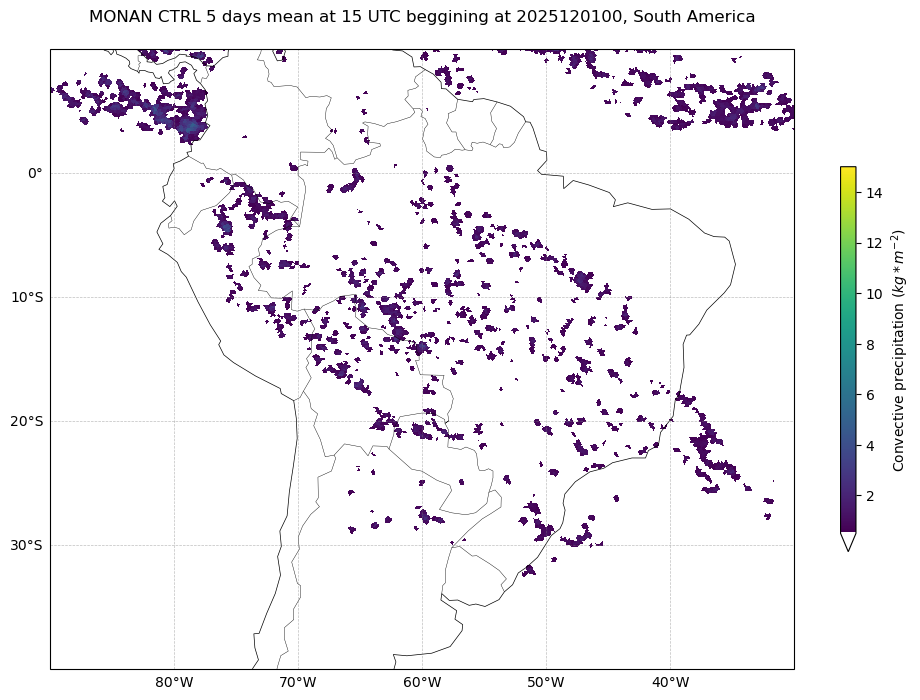

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_CTRL_SA.png


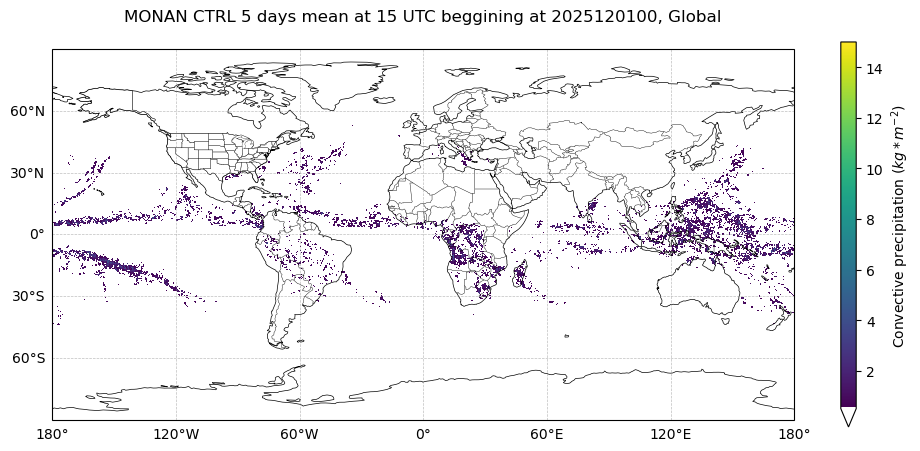

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_CTRL_Global.png
Plotting for experiment: teste_10deep


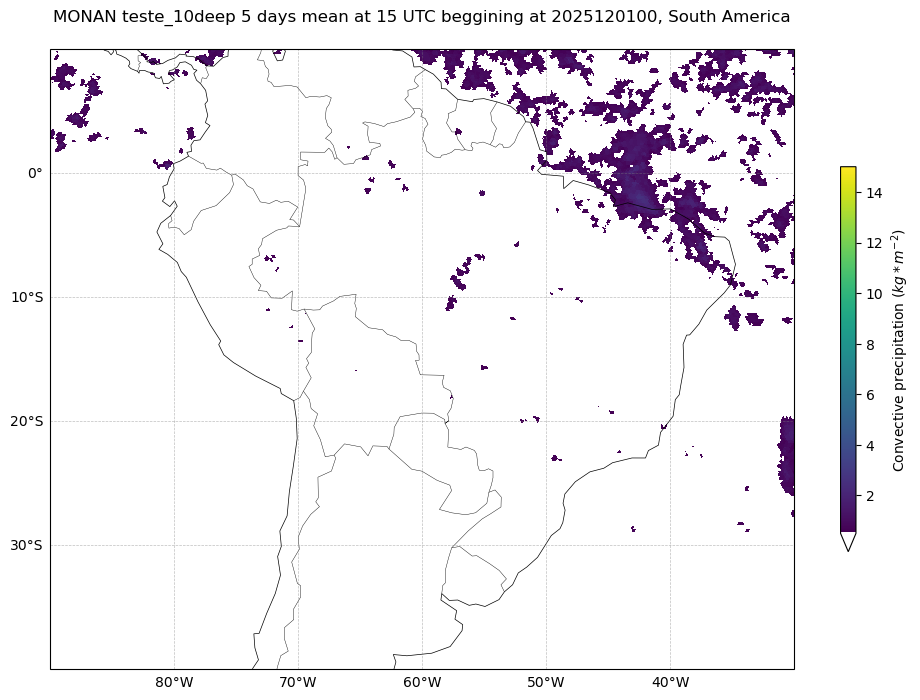

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_teste_10deep_SA.png


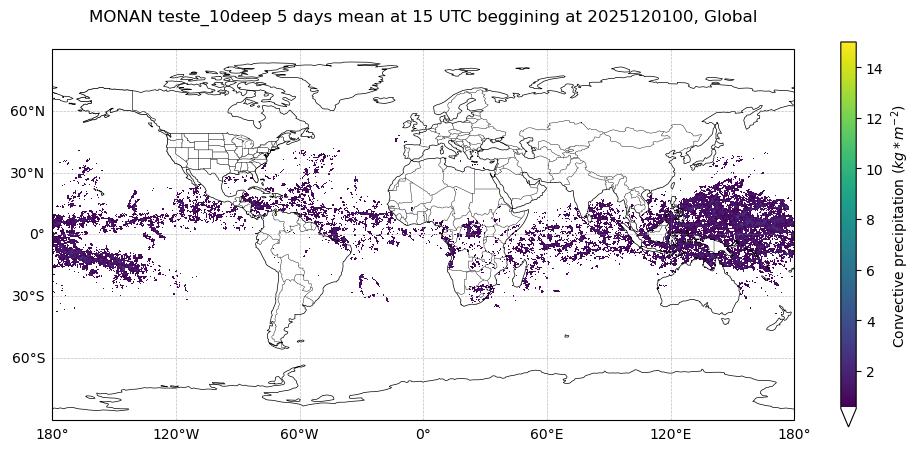

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_teste_10deep_Global.png
Plotting for experiment: teste_2deep


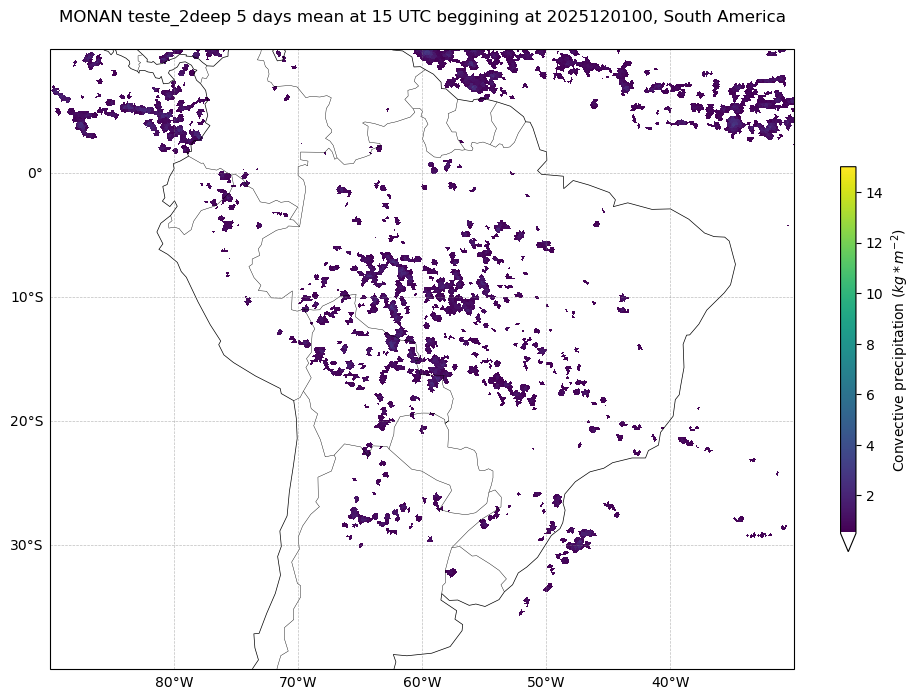

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_teste_2deep_SA.png


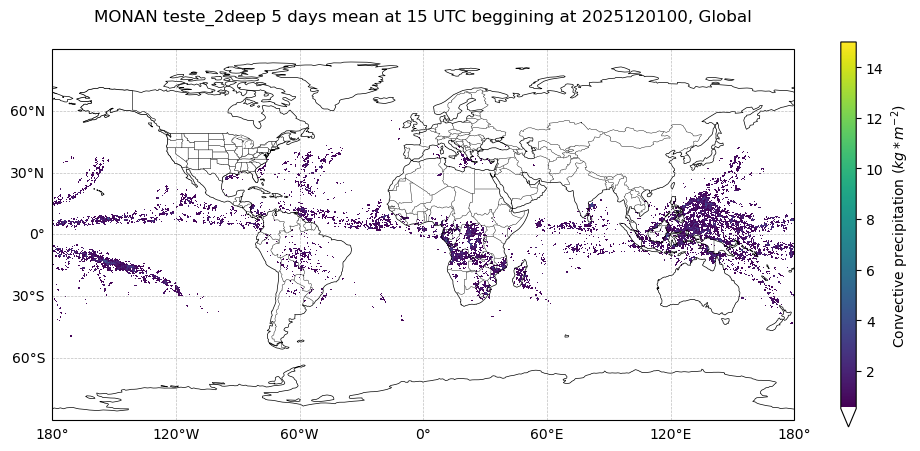

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_teste_2deep_Global.png
Plotting for experiment: teste_2shallow


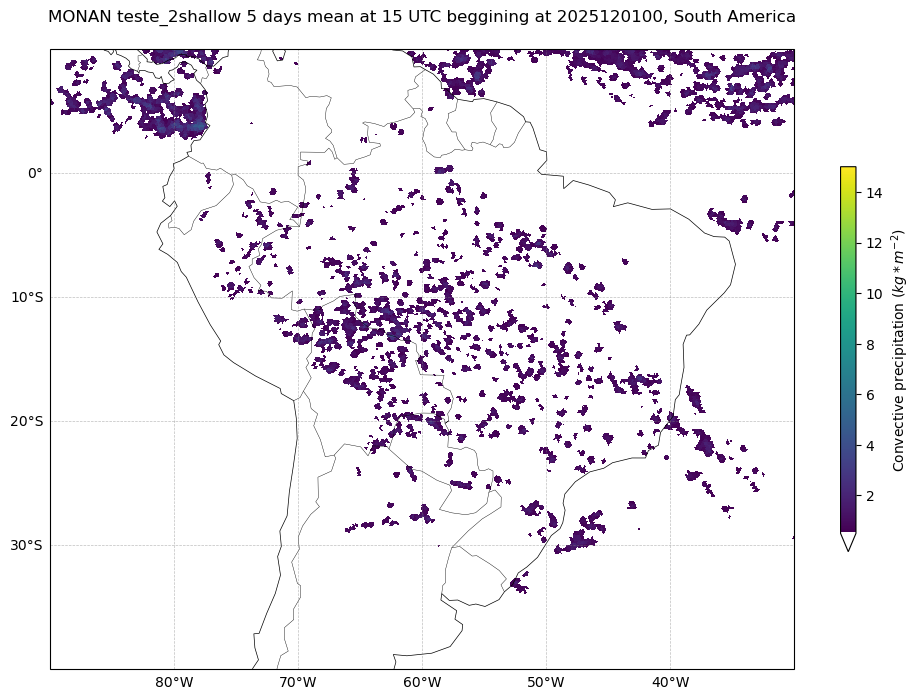

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_teste_2shallow_SA.png


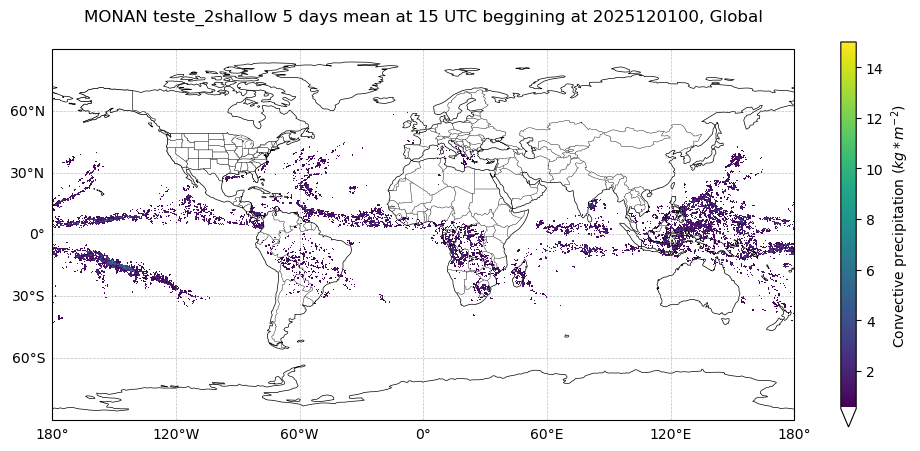

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_15_teste_2shallow_Global.png


In [105]:
#plot for exp_name
for exp in exps_data.keys():
    exp_name=exp
    print(f"Plotting for experiment: {exp_name}" )
    monan_dir=exps_data[exp]["dir"]

    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'

    monan_path = Path(monan_file)
    if os.path.exists(monan_path):    
        monan_lons = exps_data[exp]["ds_monan"]['lon'].values
        monan_lats = exps_data[exp]["ds_monan"]['lat'].values
        
        # Convert coordinates if needed
        if monan_lons.max() < 7:  # Radians (2*pi ≈ 6.28)
            monan_lons = np.rad2deg(monan_lons)
            monan_lats = np.rad2deg(monan_lats)
        # Convert longitude from 0-360 to -180 to 180
        if monan_lons.max() > 180:
            monan_lons = np.where(monan_lons > 180, monan_lons - 360, monan_lons)
        
        # Create triangulation
        tri = Triangulation(monan_lons, monan_lats)            
        # Plot using coordinates; try to orient lat/lon if dimensions suggest it
        for myext in extents.keys():
            extent_label=extents[myext]["label"]
            fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

            # Mask only negative or very small values (0.01 threshold for precipitation)
            data_to_plot = exps_data[exp]["ds_sel_time"].values
            mask_threshold = 0.01 if var in ["RAINC", "RAIN", "PC", "PI"] else var_dict[var]['vmin']
            data_masked = np.ma.masked_where(data_to_plot < mask_threshold, data_to_plot)
            
            # Create colormap with white for values below threshold
            viridis_colors = plt.cm.viridis(np.linspace(0, 1, 256))
            # Add white at the beginning for under values
            colors_with_white = np.vstack([[1, 1, 1, 1], viridis_colors])
            cmap = mcolors.ListedColormap(colors_with_white)
            cmap.set_bad(color='white')
            # Set under color to white
            cmap.set_under(color='white')
            
            # Plot
            tpc = ax.tripcolor(
                tri, data_masked, 
                cmap=cmap, 
                shading="flat",
                vmin=var_dict[var]['vmin'],
                vmax=var_dict[var]['vmax']
                )
            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            cbar = plt.colorbar(tpc, label= f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)", shrink= 0.5, aspect = 25, pad = 0.05, extend='min')

            # Add geographic features
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)

            # Add gridlines with labels
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {'size': 10}
            gl.ylabel_style = {'size': 10}

            ax.set_title(f"MONAN {exp_name} 5 days mean at {UTC_hour_plot} UTC beggining at {init}, {extent_label}", fontsize=12, pad=20)

            plt.tight_layout()
            out_png = f"{fig_path}/MONAN_{var}_{init}_5dmean_{UTC_hour_plot}_{exp_name}_{myext}.png"
            plt.savefig(out_png, dpi=150, bbox_inches='tight')
            plt.show()

            print(f"Saved plot to: {out_png}")
            plt.close()

    else:
        print(f"File does not exist: {monan_path!s}")

### Plotting mean (all hours)

Plotting 24-hour accumulation for experiment: CTRL


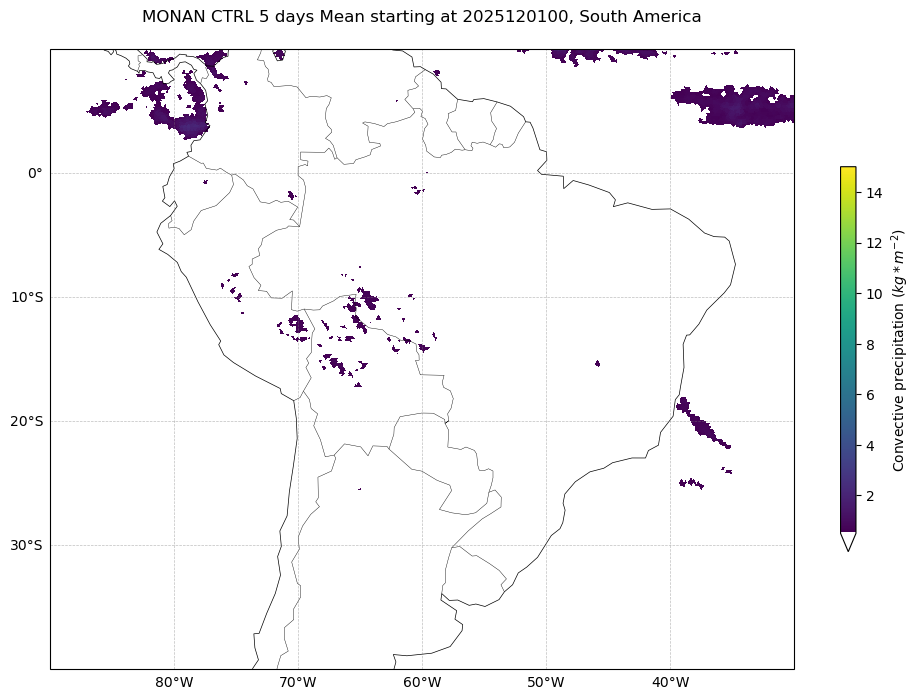

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_CTRL_SA.png


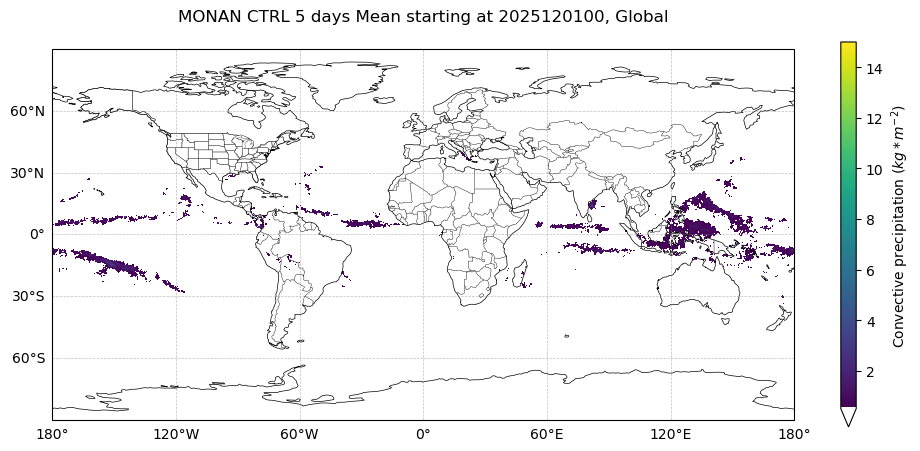

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_CTRL_Global.png
Plotting 24-hour accumulation for experiment: teste_10deep


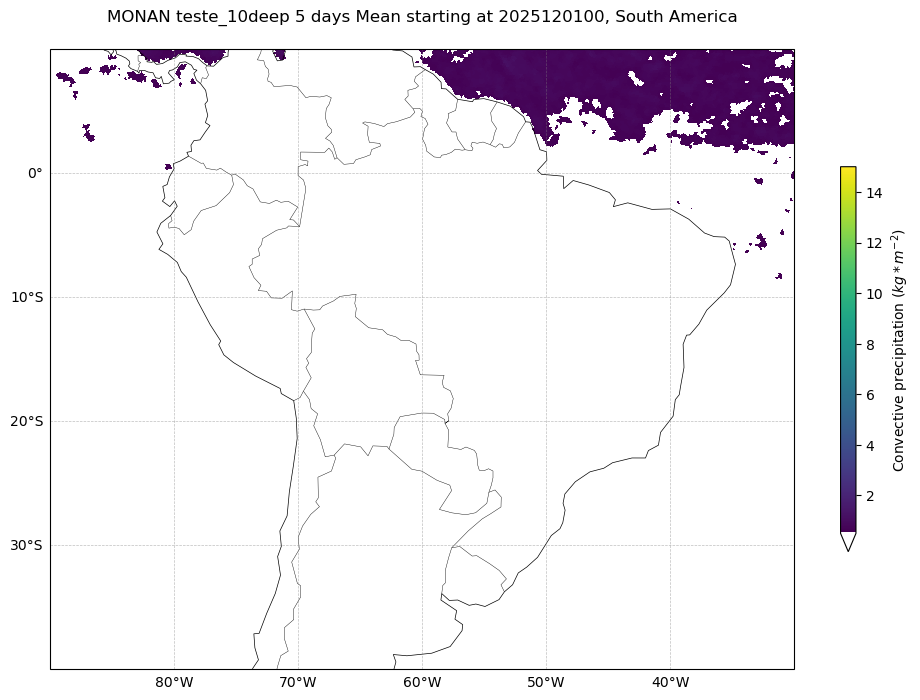

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_teste_10deep_SA.png


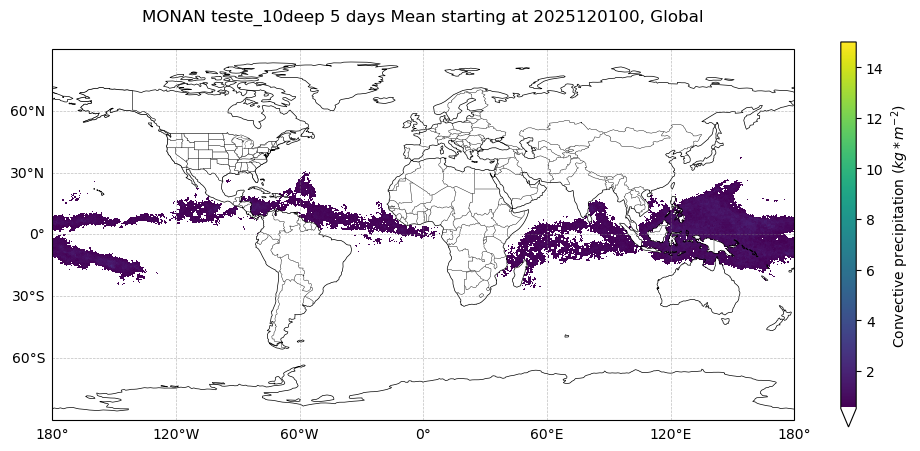

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_teste_10deep_Global.png
Plotting 24-hour accumulation for experiment: teste_2deep


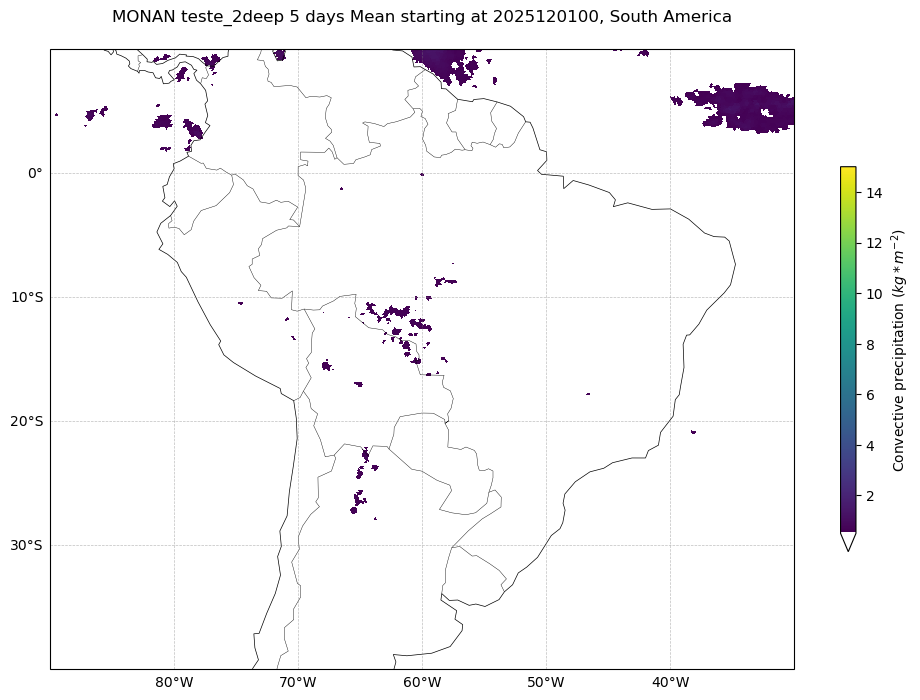

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_teste_2deep_SA.png


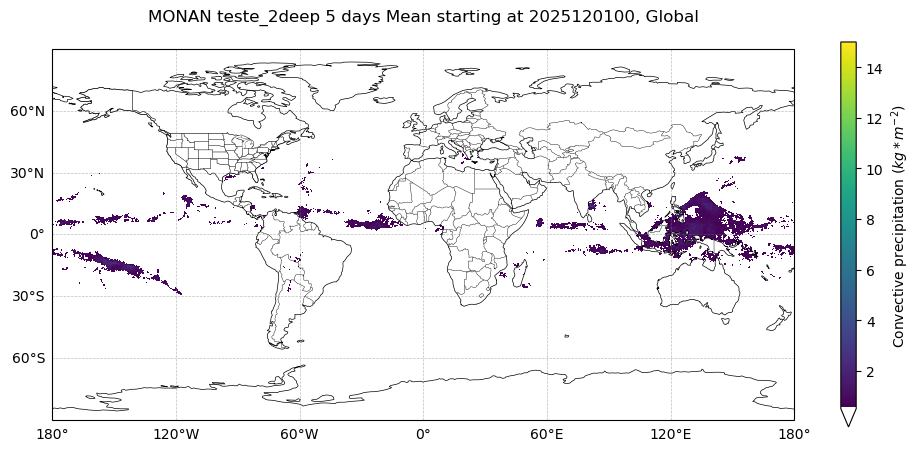

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_teste_2deep_Global.png
Plotting 24-hour accumulation for experiment: teste_2shallow


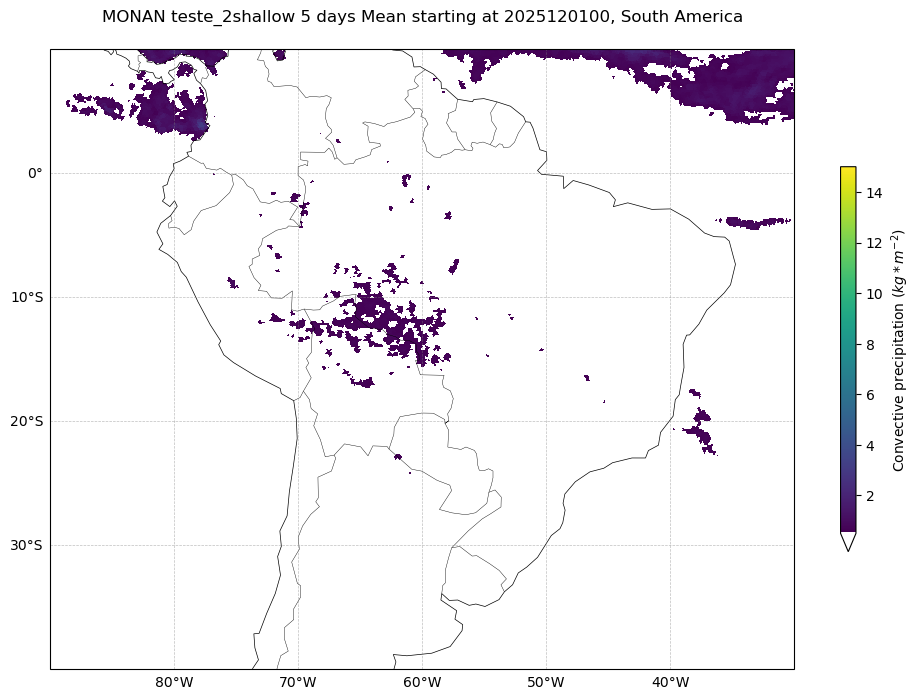

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_teste_2shallow_SA.png


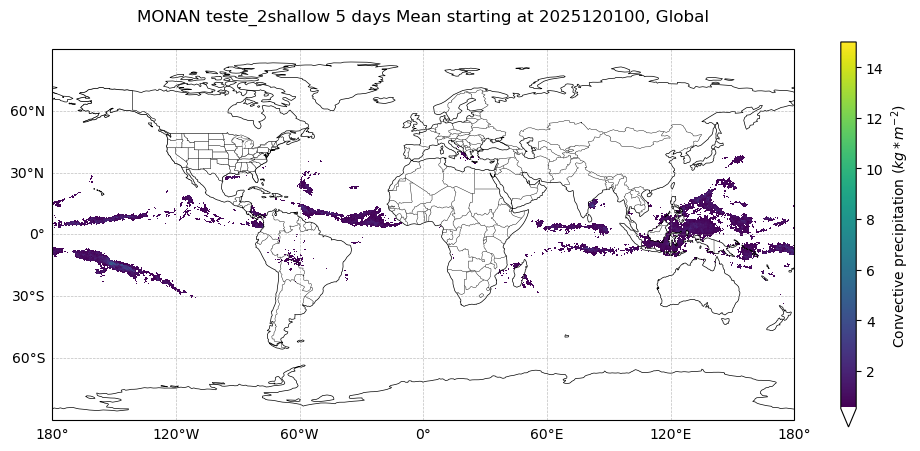

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_teste_2shallow_Global.png


In [106]:
for exp in exps_data.keys():
    exp_name=exp
    print(f"Plotting 24-hour accumulation for experiment: {exp_name}" )
    monan_dir=exps_data[exp]["dir"]

    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'

    monan_path = Path(monan_file)
    if os.path.exists(monan_path):    
        monan_lons = exps_data[exp]["ds_monan"]['lon'].values
        monan_lats = exps_data[exp]["ds_monan"]['lat'].values
        
        # Convert coordinates if needed
        if monan_lons.max() < 7:  # Radians (2*pi ≈ 6.28)
            monan_lons = np.rad2deg(monan_lons)
            monan_lats = np.rad2deg(monan_lats)
        # Convert longitude from 0-360 to -180 to 180
        if monan_lons.max() > 180:
            monan_lons = np.where(monan_lons > 180, monan_lons - 360, monan_lons)
        
        # Create triangulation
        tri = Triangulation(monan_lons, monan_lats)      
        # Plot using coordinates; try to orient lat/lon if dimensions suggest it
        for myext in extents.keys():
            extent_label=extents[myext]["label"]
            fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

            # Mask values below vmin
            data_to_plot = exps_data[exp]["ds_mean"].values
            data_masked = np.ma.masked_where(data_to_plot < var_dict[var]['vmin'], data_to_plot)
            
            # Create colormap with white for values below vmin
            viridis_colors = plt.cm.viridis(np.linspace(0, 1, 256))
            # Add white at the beginning for under values
            colors_with_white = np.vstack([[1, 1, 1, 1], viridis_colors])
            cmap = mcolors.ListedColormap(colors_with_white)
            cmap.set_bad(color='white')
            # Set under color to white
            cmap.set_under(color='white')
            
            # Plot
            tpc = ax.tripcolor(
                tri, data_masked, 
                cmap=cmap, 
                shading="flat",
                vmin=var_dict[var]['vmin'],
                vmax=var_dict[var]['vmax']
                )
            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            cbar = plt.colorbar(tpc, label= f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)", shrink= 0.5, aspect = 25, pad = 0.05, extend='min')

            # Add geographic features
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)

            # Add gridlines with labels
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {'size': 10}
            gl.ylabel_style = {'size': 10}

            ax.set_title(f"MONAN {exp_name} 5 days Mean starting at {init}, {extent_label}", fontsize=12, pad=20)

            plt.tight_layout()
            out_png = f"{fig_path}/MONAN_{var}_{init}_5dmean_{exp_name}_{myext}.png"
            plt.savefig(out_png, dpi=150, bbox_inches='tight')
            plt.show()

            print(f"Saved plot to: {out_png}")
            plt.close()

    else:
        print(f"File does not exist: {monan_path!s}")

## Plotting differences between other experiments and CTRL

['teste_10deep', 'teste_2deep', 'teste_2shallow']
Plotting 24-hour accumulation for experiment: teste_10deep


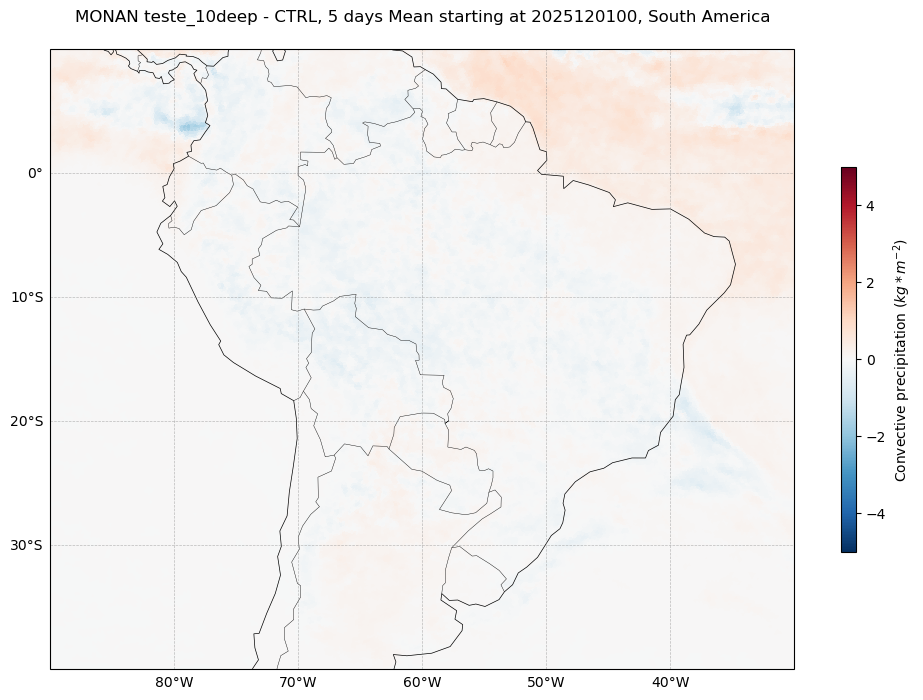

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_diff_teste_10deep_SA.png


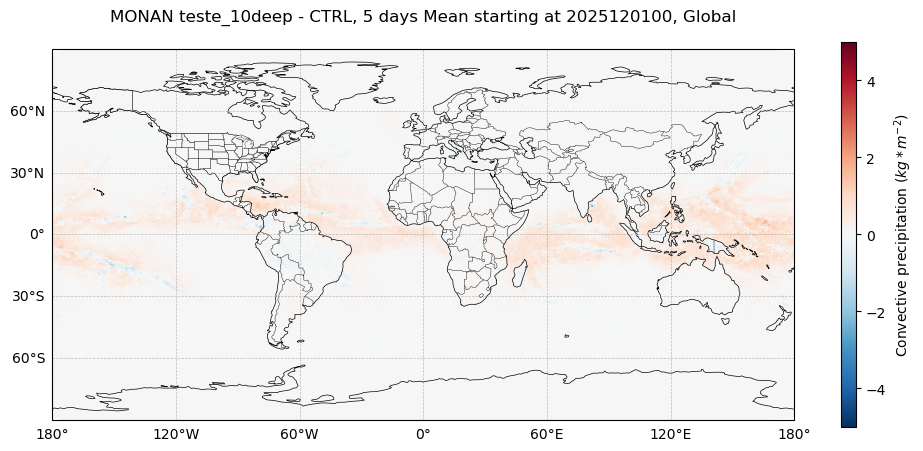

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_diff_teste_10deep_Global.png
Plotting 24-hour accumulation for experiment: teste_2deep


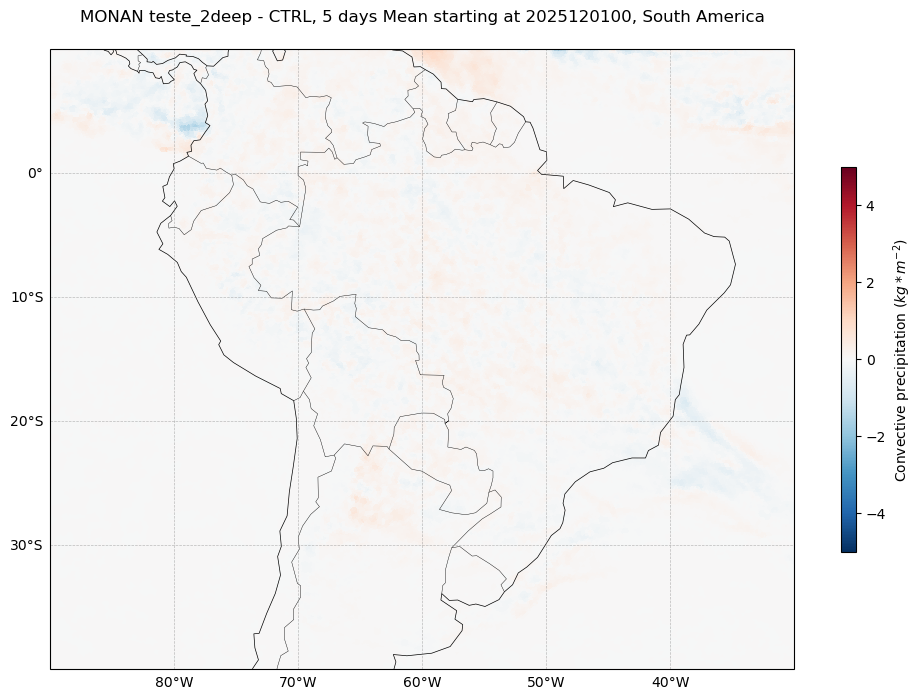

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_diff_teste_2deep_SA.png


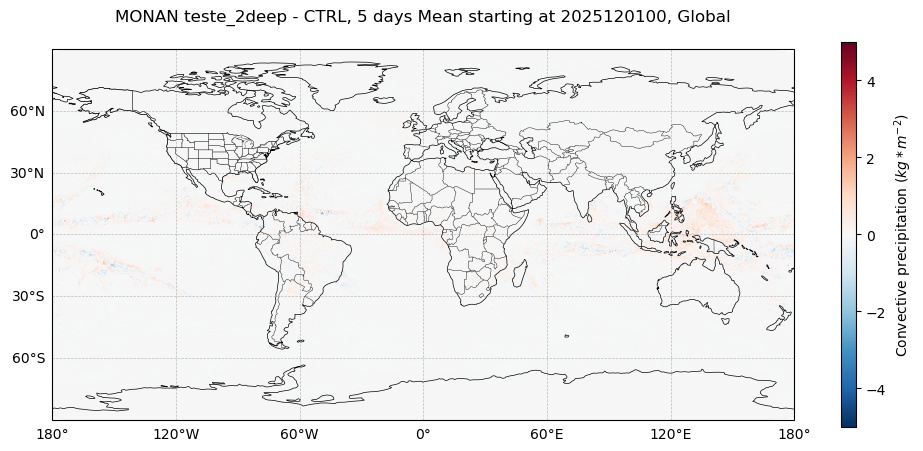

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_diff_teste_2deep_Global.png
Plotting 24-hour accumulation for experiment: teste_2shallow


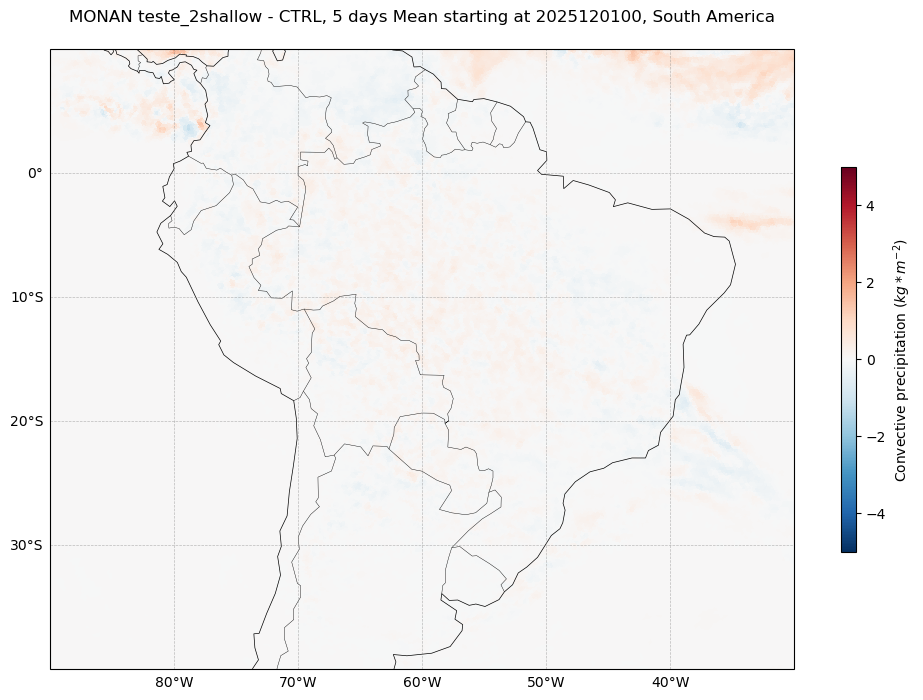

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_diff_teste_2shallow_SA.png


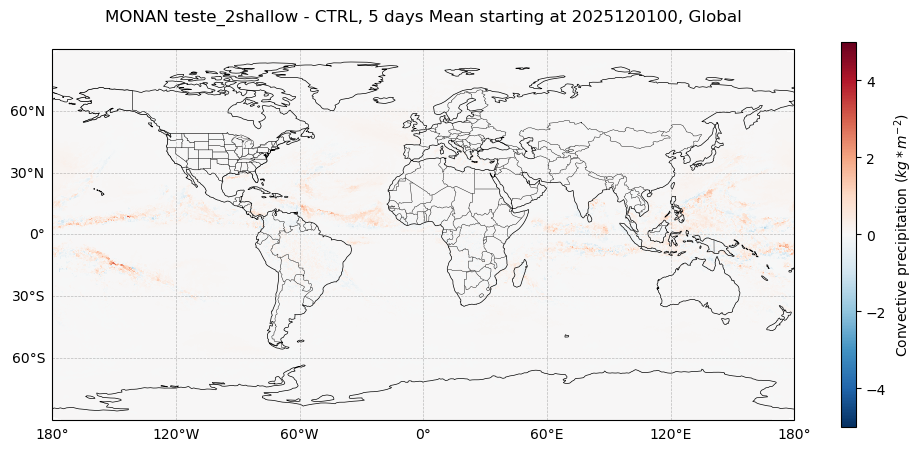

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//MONAN_RAINC_2025120100_5dmean_diff_teste_2shallow_Global.png


In [107]:
exps_noCTR=[exp for exp in exps_data.keys() if exp != "CTRL"]
print(exps_noCTR)
for exp_name in exps_noCTR:
    print(f"Plotting 24-hour accumulation for experiment: {exp_name}" )
    monan_dir=exps_data[exp_name]["dir"]

    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'

    monan_path = Path(monan_file)
    if os.path.exists(monan_path):    
        monan_lons = exps_data[exp_name]["ds_monan"]['lon'].values
        monan_lats = exps_data[exp_name]["ds_monan"]['lat'].values
        
        # Convert coordinates if needed
        if monan_lons.max() < 7:  # Radians (2*pi ≈ 6.28)
            monan_lons = np.rad2deg(monan_lons)
            monan_lats = np.rad2deg(monan_lats)
        # Convert longitude from 0-360 to -180 to 180
        if monan_lons.max() > 180:
            monan_lons = np.where(monan_lons > 180, monan_lons - 360, monan_lons)
        
        # Create triangulation
        tri = Triangulation(monan_lons, monan_lats)      
        # Plot using coordinates; try to orient lat/lon if dimensions suggest it
        for myext in extents.keys():
            extent_label=extents[myext]["label"]
            fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

            # Calculate difference
            diff_data = exps_data[exp_name]["ds_mean"].values - exps_data['CTRL']["ds_mean"].values
            
            # Mask values between -vmin_diff and vmin_diff
            threshold = abs(var_dict[var]['vmin_diff'])
            data_masked = np.ma.masked_where(np.abs(diff_data) < threshold, diff_data)
            
            # Create colormap with white in the middle
            # Use RdBu_r colormap but make the center white
            from matplotlib.colors import TwoSlopeNorm
            
            # Plot
            tpc = ax.tripcolor(
                tri, data_masked, 
                cmap="RdBu_r", 
                shading="flat",
                norm=TwoSlopeNorm(vmin=var_dict[var]['vmin_diff'], vcenter=0, vmax=var_dict[var]['vmax_diff'])
                )
            ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
            plt.colorbar(tpc, label= f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)", shrink= 0.5, aspect = 25, pad = 0.05)

            # Add geographic features
            ax.coastlines(linewidth=0.5)
            ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            ax.add_feature(cfeature.STATES, linewidth=0.2)

            # Add gridlines with labels
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.xlabel_style = {'size': 10}
            gl.ylabel_style = {'size': 10}

            ax.set_title(f"MONAN {exp_name} - CTRL, 5 days Mean starting at {init}, {extent_label}", fontsize=12, pad=20)

            plt.tight_layout()

            out_png = f"{fig_path}/MONAN_{var}_{init}_5dmean_diff_{exp_name}_{myext}.png"   

            plt.savefig(out_png, dpi=150, bbox_inches='tight')    


            plt.show()

            plt.close()
            print(f"Saved plot to: {out_png}")

## Extracting CERES {var} data from opened file

In [108]:
print(var_dict[var]['monan_name'])

rainc


In [109]:
# ceres_var_name = var_dict[var]['ceres_name']
# print(f"Trying reading dataset: {ceres_var_name}")
# if ceres_var_name in ceres_names:
#     sds = sd.select(ceres_var_name)
#     CER_data = sds.get()              
#     print(f"{sds.info()}") # shows name, rank, dims, type
#     dims = sds.info()[2]

#     #     # Apply scale/offset if present in attributes
#     attrs = sds.attributes()

#     scale = attrs.get('scale_factor') or attrs.get('scale') or attrs.get('SCALE')
#     offset = attrs.get('add_offset') or attrs.get('offset') or attrs.get('OFFSET')
#     fillvalue  = attrs.get('fill_value') or attrs.get('_FillValue')
#     datamin,datamax = attrs.get('valid_range')
#     unit = attrs.get('units')

#     if scale is not None:
#         CER_data = CER_data * float(scale)
#     if offset is not None:
#         CER_data = CER_data + float(offset)
#     CER_data_masked = np.where(CER_data < datamax, CER_data, np.nan) 

#     if unit == "cm":
#         # converting to kg/m2
#         CER_data_masked = CER_data_masked * 10
#     elif unit == "g m-2":
#         # converting to kg/m2
#         CER_data_masked = CER_data_masked / 1000

#     # Find longitude and latitude coordinates for georeferenced plotting
#     lon_coords = None
#     lat_coords = None
#     lon_names = [n for n in ceres_names if 'lon' in n.lower() or 'longitude' in n.lower()]
#     for lname in lon_names:
#         try:
#             lds = sd.select(lname)
#             try:
#                 lvals = lds.get()
#             except Exception:
#                 lvals = lds[:]
#             lon_coords = np.array(lvals)
#             try:
#                 lds.end()
#             except Exception:
#                 pass
#             break
#         except Exception:
#             continue
#     lat_names = [n for n in ceres_names if 'lat' in n.lower() or 'latitude' in n.lower()]
#     for lname in lat_names:
#         try:
#             lds = sd.select(lname)
#             try:
#                 lvals = lds.get()
#             except Exception:
#                 lvals = lds[:]
#             lat_coords = np.array(lvals)
#             try:
#                 lds.end()
#             except Exception:
#                 pass
#             break
#         except Exception:
#             continue

#     #     Getting GMT time
#     hour_data = sd.select('gmt_hr_index').get()

#     if (len(dims)>3 and 5 in dims):      
#     #     We have a cloud layer dim
#         cld_index = sd.select('cloud_layer').get()


#     # # Creating Xarray
#     if (len(dims)>3 and 5 in dims):      
#     #     Have a cloud layer dim
#         if "CER_data_xa" in locals() and isinstance(locals()["CER_data_xa"], xr.Dataset):
#             print(f'Adding {ceres_var_name} to dataArray')
#             CER_data_xa[ceres_var_name] = (("cloud_layer","gmt_hr_index", "lat", "lon"), CER_data_masked)
#         else:
#             print('Creating DataSet')
#             CER_data_xa = xr.Dataset(
#                 {
#                     ceres_var_name: (("cloud_layer", "gmt_hr_index", "lat", "lon"), CER_data_masked)
#                 },
#                 coords={
#                     "cloud_layer": cld_index,
#                     "gmt_hr_index": hour_data,
#                     "lat": lat_coords,
#                     "lon": lon_coords,
#                 }
#             )
#     else:
#     #     Have a cloud layer dim
#         if "CER_data_xa" in locals() and isinstance(locals()["CER_data_xa"], xr.Dataset):
#             print(f'Adding {ceres_var_name} to dataArray')
#             CER_data_xa[ceres_var_name] = (("gmt_hr_index", "lat", "lon"), CER_data_masked)
#         else:
#             print('Creating DataSet')
#             CER_data_xa = xr.Dataset(
#                 {
#                     ceres_var_name: (( "gmt_hr_index", "lat", "lon"), CER_data_masked)
#                 },
#                 coords={
#                     "gmt_hr_index": hour_data,
#                     "lat": lat_coords,
#                     "lon": lon_coords,
#                 }
#             )

#     # Adjusting sign of OLR / OLRC as negative outgoing
#     if var=="OLR" or var=="OLRC":
#         CER_data_xa[ceres_var_name] = 0 - CER_data_xa[ceres_var_name]

#     utc_hours = CER_data_xa['gmt_hr_index'].values   # shape (24,)
#     lon = CER_data_xa['lon'].values                  # shape (360,)

#     # Longitude offset in hours
#     lon_offset_hours = lon / 15.0

#     # Broadcast to (gmt_hr_index, lon)
#     local_hour = (utc_hours[:, None] + lon_offset_hours[None, :]) % 24
#     local_hour = local_hour.astype(int)

#     # Assign as coordinate
#     CER_data_xa = CER_data_xa.assign_coords(local_hour=(("gmt_hr_index", "lon"), local_hour))
# else:
#     print(f"Variable {ceres_var_name} not found in CERES SYN1deg-MHour file.")

## Plotting CERES {var} data at {UTC_hour_plot}

In [110]:
# if ceres_var_name in ceres_names:
#     CER_data_sel_time = CER_data_xa.where(CER_data_xa['gmt_hr_index'] == UTC_hour_plot, drop=True)

#     # Plot for each extent
#     for myext in extents.keys():
#         extent_label = extents[myext]["label"]
#         fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

#         # Plot the data (sorted by latitude to avoid ValueError)
#         im = CER_data_sel_time[ceres_var_name].plot(
#             ax=ax, 
#             cmap='RdYlBu_r',
#             vmin=var_dict[var]['vmin'],
#             vmax=var_dict[var]['vmax'],
#             cbar_kwargs={
#                 'shrink': 0.5,  # Make colorbar 70% of the plot height
#                 'aspect': 25,   # Control width (higher = thinner)
#                 'pad': 0.05,    # Space between plot and colorbar
#                 'label': f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)"
#             }
#         )
        
#         ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())

#         # Add geographic features
#         ax.coastlines(linewidth=0.5)
#         ax.add_feature(cfeature.BORDERS, linewidth=0.3)
#         ax.add_feature(cfeature.STATES, linewidth=0.2)

#         # Add gridlines with labels
#         gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
#         gl.top_labels = False
#         gl.right_labels = False
#         gl.xlabel_style = {'size': 10}
#         gl.ylabel_style = {'size': 10}

#         ax.set_title(f"CER_SYN1deg Ed4A Monthly Mean at {UTC_hour_plot} UTC for {year}-{month}, {extent_label}", fontsize=12, pad=20)

#         plt.tight_layout()
#         out_png = f"{fig_path}/CER_SYN1deg_Ed4A_{var}_{year}_{month}_{UTC_hour_plot}_{myext}.png"
#         plt.savefig(out_png, dpi=150, bbox_inches='tight')
#         plt.show()

#         print(f"Saved plot to: {out_png}")
#         plt.close()
        
# else:
#     print(f"{ceres_var_name} not found in CERES dataset.")

#### Plotting CERES {var}monthly mean data 

In [111]:
# if ceres_var_name in ceres_names:
#     CER_data_all_time = CER_data_xa[ceres_var_name].mean(dim='gmt_hr_index')

#     # Plot for each extent
#     for myext in extents.keys():
#         extent_label = extents[myext]["label"]
#         fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

#         # Plot the data (sorted by latitude to avoid ValueError)
#         im = CER_data_all_time.plot(
#             ax=ax, 
#             cmap='RdYlBu_r',
#             vmin=var_dict[var]['vmin'],
#             vmax=var_dict[var]['vmax'],
#             cbar_kwargs={
#                 'shrink': 0.5,  # Make colorbar 70% of the plot height
#                 'aspect': 25,   # Control width (higher = thinner)
#                 'pad': 0.05,    # Space between plot and colorbar
#                 'label': f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)"
#             }
#         )
        
#         ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())

#         # Add geographic features
#         ax.coastlines(linewidth=0.5)
#         ax.add_feature(cfeature.BORDERS, linewidth=0.3)
#         ax.add_feature(cfeature.STATES, linewidth=0.2)

#         # Add gridlines with labels
#         gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
#         gl.top_labels = False
#         gl.right_labels = False
#         gl.xlabel_style = {'size': 10}
#         gl.ylabel_style = {'size': 10}

#         ax.set_title(f"CER_SYN1deg Ed4A Monthly Mean for {year}-{month}, {extent_label}", fontsize=12, pad=20)

#         plt.tight_layout()
#         out_png = f"{fig_path}/CER_SYN1deg_Ed4A_{var}_{year}_{month}_mean_{myext}.png"
#         plt.savefig(out_png, dpi=150, bbox_inches='tight')
#         plt.show()

#         print(f"Saved plot to: {out_png}")
#         plt.close()

# else:
#     print(f"{ceres_var_name} not found in CERES dataset.")

## Opening ERA5 {var} data

In [112]:
era5_file_arg = base_dir+f"era5/single_levels/{year}/{month}/{var_dict[var]['era5_longname']}.nc"
era5_path = Path(era5_file_arg)
if not os.path.exists(era5_path):    
    print(f"File does not exist: {era5_path}")
else:
    ds_era5 = xr.open_dataset(era5_path, engine="netcdf4")
    ds_era5 = apply_lon_lat_conventions(ds_era5)

    if var_dict[var]["convert_to_flux"]=="yes":
        ds_era5[era_var_name] = ds_era5[var_dict[var]["era5_name"]]/3600
        ds_era5[era_var_name].attrs = {'units': var_dict[var]["unit"]}
        ds_era5[era_var_name].attrs['description'] = f'Instantaneous flux calculated from accumulated {var_dict[var]["era5_name"].upper()}'
        print(ds_era5[era_var_name].attrs)
        print(ds_era5['valid_time'])
    else:
        print(ds_era5[var_dict[var]["era5_name"]].attrs)


{'GRIB_paramId': np.int64(143), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(1038240), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'accum', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(1440), 'GRIB_Ny': np.int64(721), 'GRIB_cfName': 'lwe_thickness_of_convective_precipitation_amount', 'GRIB_cfVarName': 'cp', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(90.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-90.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(0.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(359.75), 'GRIB_missingValue': np.float64(3.402823466385

## Plotting ERA5 {var} data at {UTC_hour_plot}

/home2/madeleine.gacita/.conda/envs/working_env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


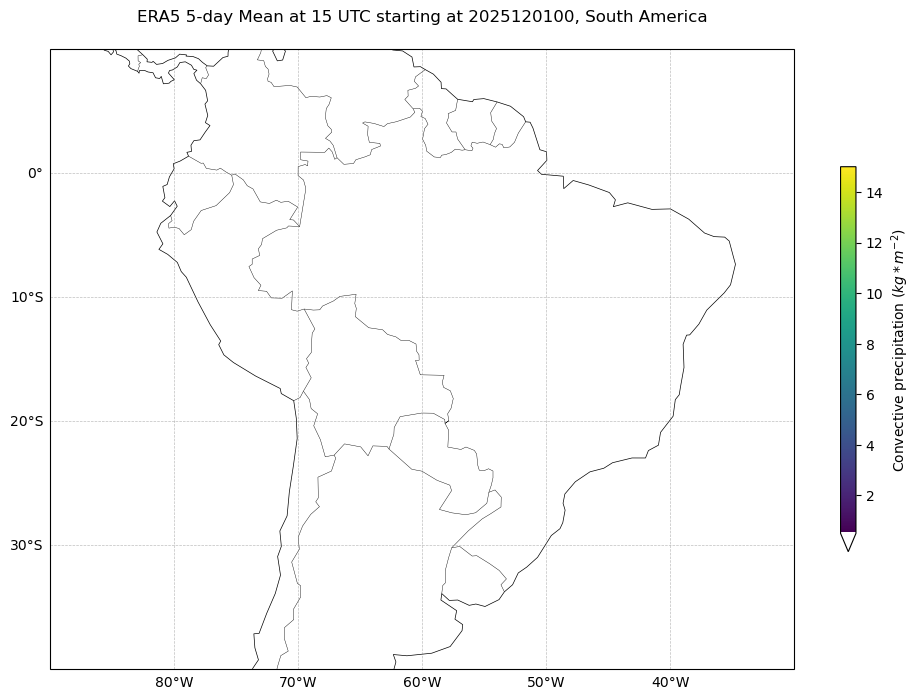

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_RAINC_2025120100_5dmean_15_SA.png


/home2/madeleine.gacita/.conda/envs/working_env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


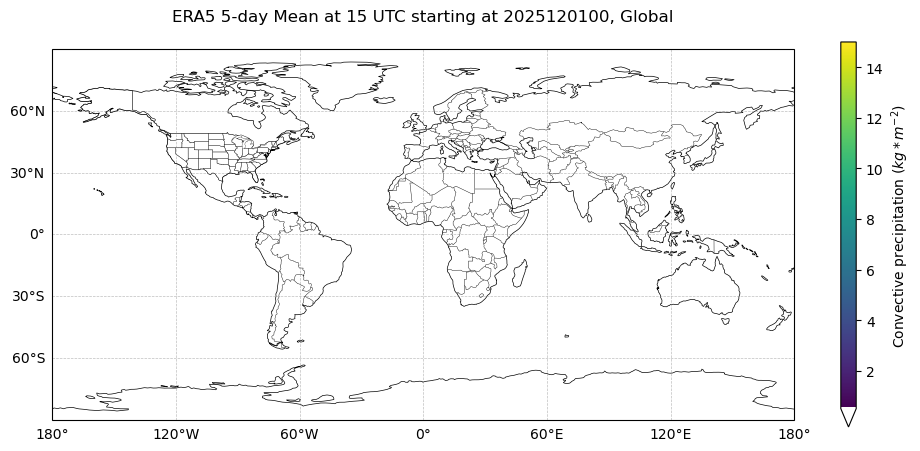

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_RAINC_2025120100_5dmean_15_Global.png


In [113]:
if os.path.exists(era5_path):  
    ds_era5_sel_time = ds_era5.where(ds_era5['valid_time'].dt.hour == UTC_hour_plot, drop=True).mean(dim='valid_time')

    # Plot for each extent
    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

        # Mask values below vmin
        data_to_plot = ds_era5_sel_time[era_var_name]
        data_masked = data_to_plot.where(data_to_plot >= var_dict[var]['vmin'])
        
        # Create colormap with white for values below vmin
        viridis_colors = plt.cm.viridis(np.linspace(0, 1, 256))
        # Add white at the beginning for under values
        colors_with_white = np.vstack([[1, 1, 1, 1], viridis_colors])
        cmap = mcolors.ListedColormap(colors_with_white)
        cmap.set_bad(color='white')
        # Set under color to white
        cmap.set_under(color='white')
        
        # Plot the data (sorted by latitude to avoid ValueError)
        im = data_masked.plot(
            ax=ax, 
            cmap=cmap,
            vmin=var_dict[var]['vmin'],
            vmax=var_dict[var]['vmax'],
            cbar_kwargs={
                'shrink': 0.5,  # Make colorbar 70% of the plot height
                'aspect': 25,   # Control width (higher = thinner)
                'pad': 0.05,    # Space between plot and colorbar
                'label': f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)",
                'extend': 'min'
            }
        )
        
        ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())

        # Add geographic features
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)

        # Add gridlines with labels
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}

        # Set title
        ax.set_title(f"ERA5 5-day Mean at {UTC_hour_plot} UTC starting at {init}, {extent_label}", fontsize=12, pad=20)

        plt.tight_layout()
        out_png = f"{fig_path}/ERA5_{var}_{init}_5dmean_{UTC_hour_plot}_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"Saved plot to: {out_png}")
        plt.close()

## Plotting ERA5 {var} monthly mean data

/home2/madeleine.gacita/.conda/envs/working_env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


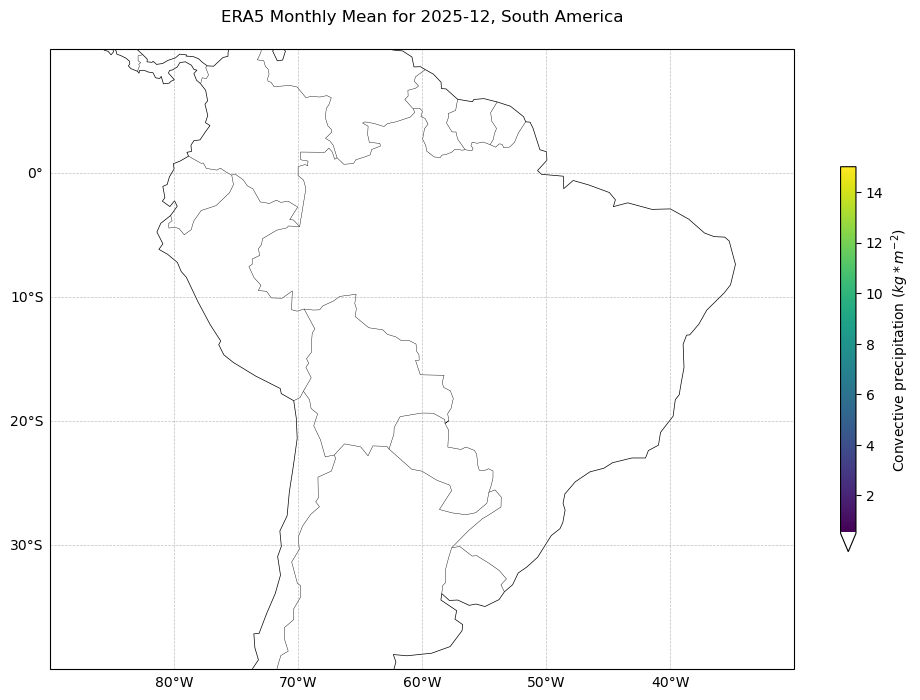

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_RAINC_2025_12_mean_SA.png


/home2/madeleine.gacita/.conda/envs/working_env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


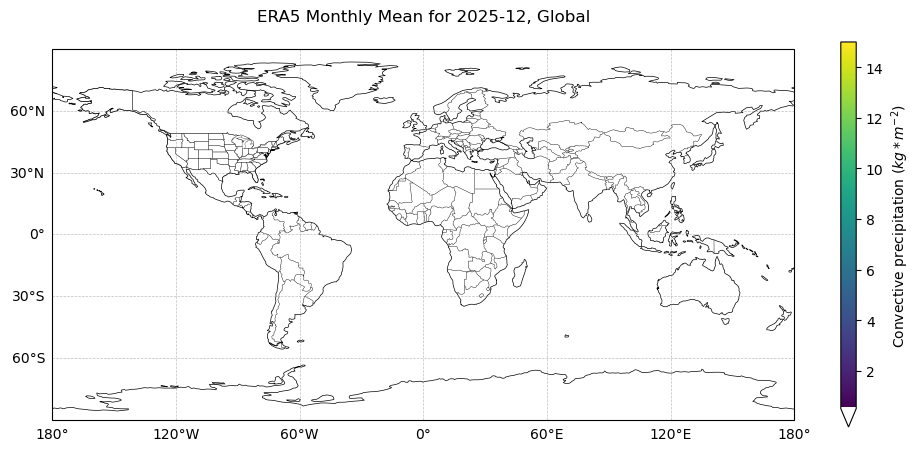

Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//ERA5_RAINC_2025_12_mean_Global.png


In [114]:
if os.path.exists(era5_path):  
    ds_era5_all_time = ds_era5.mean(dim='valid_time')

    # Plot for each extent
    for myext in extents.keys():
        extent_label = extents[myext]["label"]
        fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))

        # Mask values below vmin
        data_to_plot = ds_era5_all_time[era_var_name]
        data_masked = data_to_plot.where(data_to_plot >= var_dict[var]['vmin'])
        
        # Create colormap with white for values below vmin
        viridis_colors = plt.cm.viridis(np.linspace(0, 1, 256))
        # Add white at the beginning for under values
        colors_with_white = np.vstack([[1, 1, 1, 1], viridis_colors])
        cmap = mcolors.ListedColormap(colors_with_white)
        cmap.set_bad(color='white')
        # Set under color to white
        cmap.set_under(color='white')
        
        # Plot the data (sorted by latitude to avoid ValueError)
        im = data_masked.plot(
            ax=ax, 
            cmap=cmap,
            vmin=var_dict[var]['vmin'],
            vmax=var_dict[var]['vmax'],
            cbar_kwargs={
                'shrink': 0.5,  # Make colorbar 70% of the plot height
                'aspect': 25,   # Control width (higher = thinner)
                'pad': 0.05,    # Space between plot and colorbar
                'label': f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)",
                'extend': 'min'
            }
        )
        
        ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())

        # Add geographic features
        ax.coastlines(linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, linewidth=0.2)

        # Add gridlines with labels
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10}
        gl.ylabel_style = {'size': 10}

        # Set title
        ax.set_title(f"ERA5 Monthly Mean for {year}-{month}, {extent_label}", fontsize=12, pad=20)

        plt.tight_layout()
        out_png = f"{fig_path}/ERA5_{var}_{year}_{month}_mean_{myext}.png"
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"Saved plot to: {out_png}")
        plt.close()

## Plotting MONAN - ERA5 {var} data at {UTC_hour_plot}

In [115]:
if os.path.exists(era5_path):  
    ds_era5_all_time = ds_era5.mean(dim='valid_time')

    for exp in exps_data.keys():
        exp_name=exp
        print(f"Plotting for experiment: {exp_name}" )
        monan_dir=exps_data[exp]["dir"]

        monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'

        monan_path = Path(monan_file)
        if os.path.exists(monan_path):    
            # Get coordinates for interpolation
            monan_lons = exps_data[exp]["ds_monan"]['lon'].values
            monan_lats = exps_data[exp]["ds_monan"]['lat'].values
            
            # Convert coordinates if needed
            if monan_lons.max() < 7:  # Radians (2*pi ≈ 6.28)
                monan_lons = np.rad2deg(monan_lons)
                monan_lats = np.rad2deg(monan_lats)
            # Convert longitude from 0-360 to -180 to 180
            if monan_lons.max() > 180:
                monan_lons = np.where(monan_lons > 180, monan_lons - 360, monan_lons)
            
            # Interpolate ERA5 data to MONAN grid points
            era5_at_points = ds_era5_all_time.interp(
                latitude=monan_lats,
                longitude=monan_lons)
            monan_era5 = exps_data[exp]["ds_mean"] - era5_at_points[era_var_name]
            
            # Create triangulation
            tri = Triangulation(monan_lons, monan_lats)
            
            # Plot for each extent
            for myext in extents.keys():
                extent_label=extents[myext]["label"]
                
                # Create new figure for each experiment and extent
                fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=ccrs.PlateCarree()))
                
                # Plot
                tpc = ax.tripcolor(
                    tri, monan_era5, 
                    cmap="RdBu_r", 
                    shading="flat",
                    vmin=var_dict[var]['vmin_diff'],
                    vmax=var_dict[var]['vmax_diff']
                )
                ax.set_extent(extents[myext]["extent"], crs=ccrs.PlateCarree())
                plt.colorbar(tpc, label=f"{var_dict[var]['label']} (${var_dict[var]['unit']}$)", shrink=0.5, aspect=25, pad=0.05)

                # Add geographic features
                ax.coastlines(linewidth=0.5)
                ax.add_feature(cfeature.BORDERS, linewidth=0.3)
                ax.add_feature(cfeature.STATES, linewidth=0.2)

                # Add gridlines with labels
                gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
                gl.top_labels = False
                gl.right_labels = False
                gl.xlabel_style = {'size': 10}
                gl.ylabel_style = {'size': 10}

                # Set title
                ax.set_title(f"MONAN {exp_name} - ERA5 5 days Mean for {year}-{month}, {extent_label}", fontsize=12, pad=20)


                plt.tight_layout()

                out_png = f"{fig_path}/MONAN_{exp_name}_ERA5_{var}_{year}_{month}_mean_{myext}.png"                
                plt.close()

                plt.savefig(out_png, dpi=150, bbox_inches='tight')                
                print(f"Saved plot to: {out_png}")

                plt.show()

Plotting for experiment: CTRL


MemoryError: Unable to allocate 3.13 TiB for an array with shape (655362, 655362) and data type float64

## Plotting profile at {UTC_hour_plot} and {target_lon}

### Extract ERA5 Mhourly mean data at {UTC_hour_plot} and {target_lon} 

In [ ]:
if os.path.exists(era5_path):  
    #Extract data from ERA5
    # Get the data variable at hour {UTC_hour_plot}
    era5_data_2d = ds_era5_sel_time

    # Find longitude index closest to target_lon
    era5_lon = era5_data_2d['longitude'].values
    era5_lon_idx = np.argmin(np.abs(era5_lon - target_lon))
    actual_lon = era5_lon[era5_lon_idx]

    # Extract slice at that longitude
    era5_slice = era5_data_2d.isel(longitude=era5_lon_idx)
    era5_lat = era5_slice['latitude'].values
    era5_values = era5_slice[era_var_name].values

### Extract MONAN Mhourly mean data at {UTC_hour_plot} and {target_lon} 

In [ ]:
# Extract CERES data at {UTC_hour_plot} if available
try:
    if 'ceres_var_name' in locals() and 'CER_data_xa' in locals() and isinstance(CER_data_xa, xr.Dataset):
        # Get the data variable at hour {UTC_hour_plot}
        ceres_data_2d = CER_data_sel_time

        # Find longitude index closest to target_lon
        ceres_lon_idx = np.argmin(np.abs(lon_coords - target_lon))
        actual_ceres_lon = lon_coords[ceres_lon_idx]        

        # Extract slice at that longitude
        ceres_slice = ceres_data_2d.isel(lon=ceres_lon_idx)
        ceres_lat = ceres_slice['lat'].values
        ceres_values = ceres_slice[ceres_var_name].values[0]
        print(f"CERES data extracted at lon={actual_ceres_lon:.2f}")
    else:
        print("CERES data not available - skipping extraction")
except Exception as e:
    print(f"CERES extraction skipped: {e}")

CERES data not available - skipping extraction


In [ ]:
for exp_name in exps_data.keys():
    print(f"Extracting slice for experiment: {exp_name}" )
    monan_dir=exps_data[exp_name]["dir"]
    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'
    monan_path = Path(monan_file)

    if os.path.exists(monan_path):    
        monan_lons=exps_data[exp_name]["ds_monan"]['lon'].values
        monan_lats =exps_data[exp_name]["ds_monan"]['lat'].values
        monan_data_2d = exps_data[exp_name]["ds_sel_time"].values

        # Select longitude = {target_lon} (nearest index)
        tol=0.05
        mask = np.abs(monan_lons - target_lon) < tol
        monan_lat_slice = monan_lats[mask]
        monan_slice = monan_data_2d[mask]

        # Order by latitude
        order = np.argsort(monan_lat_slice)
        exps_data[exp_name]["monan_lat_slice_sorted"] = monan_lat_slice[order]
        exps_data[exp_name]["monan_slice_sorted_selhour"] = monan_slice[order]
        print("slice extracted")
    else:
        print(f"File does not exist: {monan_path!s}")


Extracting slice for experiment: CTRL
slice extracted
Extracting slice for experiment: teste_10deep
slice extracted
Extracting slice for experiment: teste_2deep
slice extracted
Extracting slice for experiment: teste_2shallow
slice extracted


### Create the plot

Plotting latitude slice for experiment: CTRL
Plotting latitude slice for experiment: teste_2deep
Plotting latitude slice for experiment: teste_2shallow
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//RAINNC_2025120100_5dmean_15UTC_lon-60.png


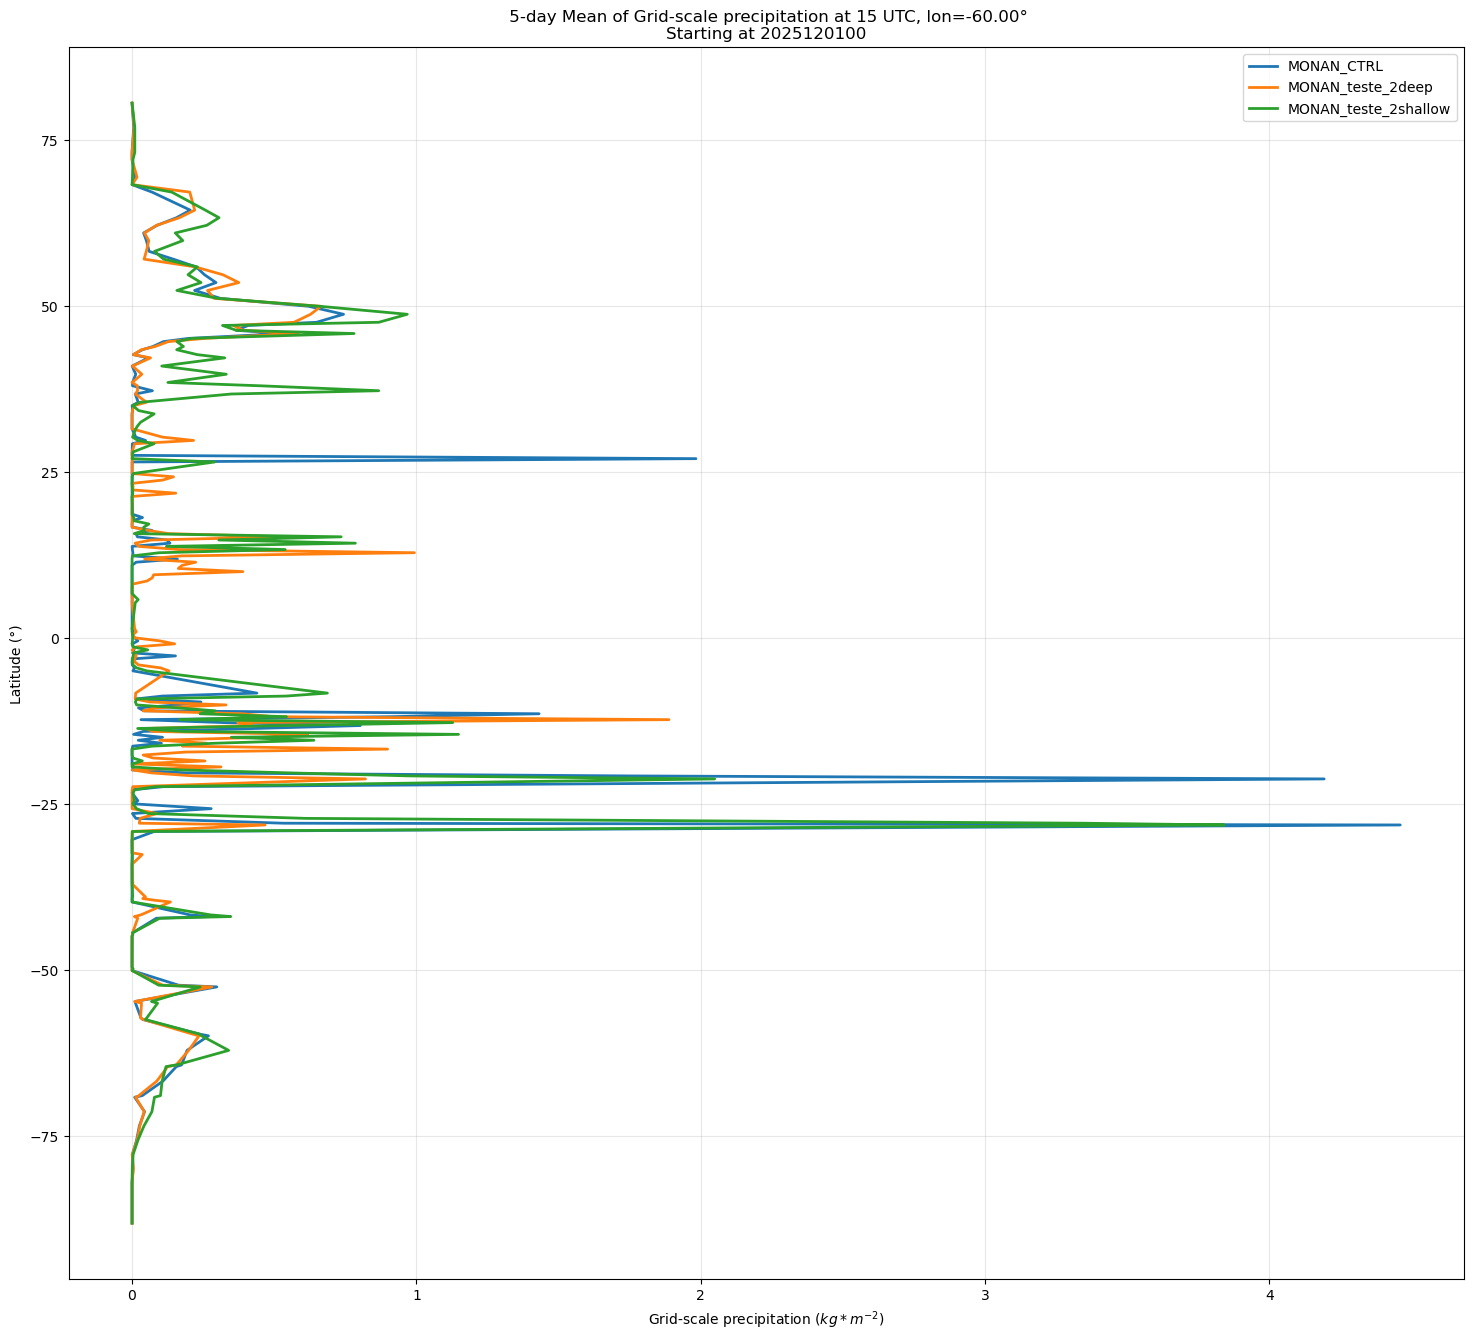

In [ ]:
plt.figure(figsize=(18, 16))
# for exp_name in exps_data.keys():
exps=[exp for exp in exps_data.keys() if exp != "teste_10deep"]
for exp_name in exps:
    print(f"Plotting latitude slice for experiment: {exp_name}" )
    monan_dir=exps_data[exp_name]["dir"]
    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'
    monan_path = Path(monan_file)

    if os.path.exists(monan_path):
        plt.plot(exps_data[exp_name]["monan_slice_sorted_selhour"], exps_data[exp_name]["monan_lat_slice_sorted"], label=f"MONAN_{exp_name}", linewidth=2)
if os.path.exists(era5_path):
    plt.plot(era5_values, era5_lat, label=f"ERA5", linewidth=2)
# Plot CERES if available
try:
    if 'ceres_var_name' in locals() and 'ceres_values' in locals():
        plt.plot(ceres_values, ceres_lat, label=f"CERES", linewidth=2)
except:
    pass  # CERES data not available yet
plt.xlabel(f"{var_dict[var]['label']} (${var_dict[var]['unit']})$")
plt.ylabel('Latitude (°)')
plt.title(f" 5-day Mean of {var_dict[var]['label']} at {UTC_hour_plot} UTC, lon={target_lon:.2f}°\nStarting at {init}")
plt.grid(True, alpha=0.3)
plt.legend()

# Save the plot
out_png = f"{fig_path}/{var}_{init}_5dmean_{UTC_hour_plot}UTC_lon{int(target_lon)}.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f"Saved plot to: {out_png}")
plt.show()
plt.close()

## Plotting profile for monthly mean and {target_lon}

### Extract ERA5 Mhourly mean data at {UTC_hour_plot} and {target_lon} 

In [ ]:
if os.path.exists(era5_path):  
    #Extract data from ERA5
    # Get the data variable at hour {UTC_hour_plot}
    era5_data_2d = ds_era5_all_time[era_var_name]

    # Find longitude index closest to target_lon
    era5_lon = era5_data_2d['longitude'].values
    era5_lon_idx = np.argmin(np.abs(era5_lon - target_lon))
    actual_lon = era5_lon[era5_lon_idx]

    # Extract slice at that longitude
    era5_slice = era5_data_2d.isel(longitude=era5_lon_idx)
    era5_lat = era5_slice['latitude'].values
    era5_values = era5_slice.values

### Extract CERES Mhourly mean data  at {UTC_hour_plot} and {target_lon} 

In [ ]:
# Extract CERES data if available
try:
    if 'ceres_var_name' in locals() and 'ceres_names' in locals() and ceres_var_name in ceres_names:
        # Get the data variable at hour {UTC_hour_plot}
        ceres_data_2d = CER_data_all_time

        # Find longitude index closest to target_lon
        ceres_lon_idx = np.argmin(np.abs(lon_coords - target_lon))
        actual_ceres_lon = lon_coords[ceres_lon_idx]        

        # Extract slice at that longitude
        ceres_slice = ceres_data_2d[:,ceres_lon_idx]
        ceres_values = ceres_slice
        print(f"CERES monthly mean data extracted at lon={actual_ceres_lon:.2f}")
    else:
        print("CERES data not available - skipping extraction")
except Exception as e:
    print(f"CERES extraction skipped: {e}")

CERES data not available - skipping extraction


### Extract MONAN Mhourly mean data at {UTC_hour_plot} and {target_lon} 

In [ ]:
for exp_name in exps_data.keys():
    print(f"Extracting slice for experiment: {exp_name}" )
    monan_dir=exps_data[exp_name]["dir"]
    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'
    monan_path = Path(monan_file)

    if os.path.exists(monan_path):    
        monan_lons=exps_data[exp_name]["ds_monan"]['lon'].values
        monan_lats =exps_data[exp_name]["ds_monan"]['lat'].values
        monan_data_2d = exps_data[exp_name]["ds_mean"].values

        # Select longitude = {target_lon} (nearest index)
        tol=0.05
        mask = np.abs(monan_lons - target_lon) < tol
        monan_lat_slice = monan_lats[mask]
        monan_slice = monan_data_2d[mask]

        # Order by latitude
        order = np.argsort(monan_lat_slice)
        exps_data[exp_name]["monan_lat_slice_sorted"] = monan_lat_slice[order]
        exps_data[exp_name]["monan_slice_sorted_monmean"] = monan_slice[order]
        print("slice extracted")
    else:
        print(f"File does not exist: {monan_path!s}")


Extracting slice for experiment: CTRL
slice extracted
Extracting slice for experiment: teste_10deep
slice extracted
Extracting slice for experiment: teste_2deep
slice extracted
Extracting slice for experiment: teste_2shallow
slice extracted


### Create the plot

Plotting latitude slice for experiment: CTRL
Plotting latitude slice for experiment: teste_2deep
Plotting latitude slice for experiment: teste_2shallow
Saved plot to: /p/projetos/monan_atm/madeleine.gacita/figuras//RAINNC_2025120100_24_accum_lon-60_teste_2shallow.png


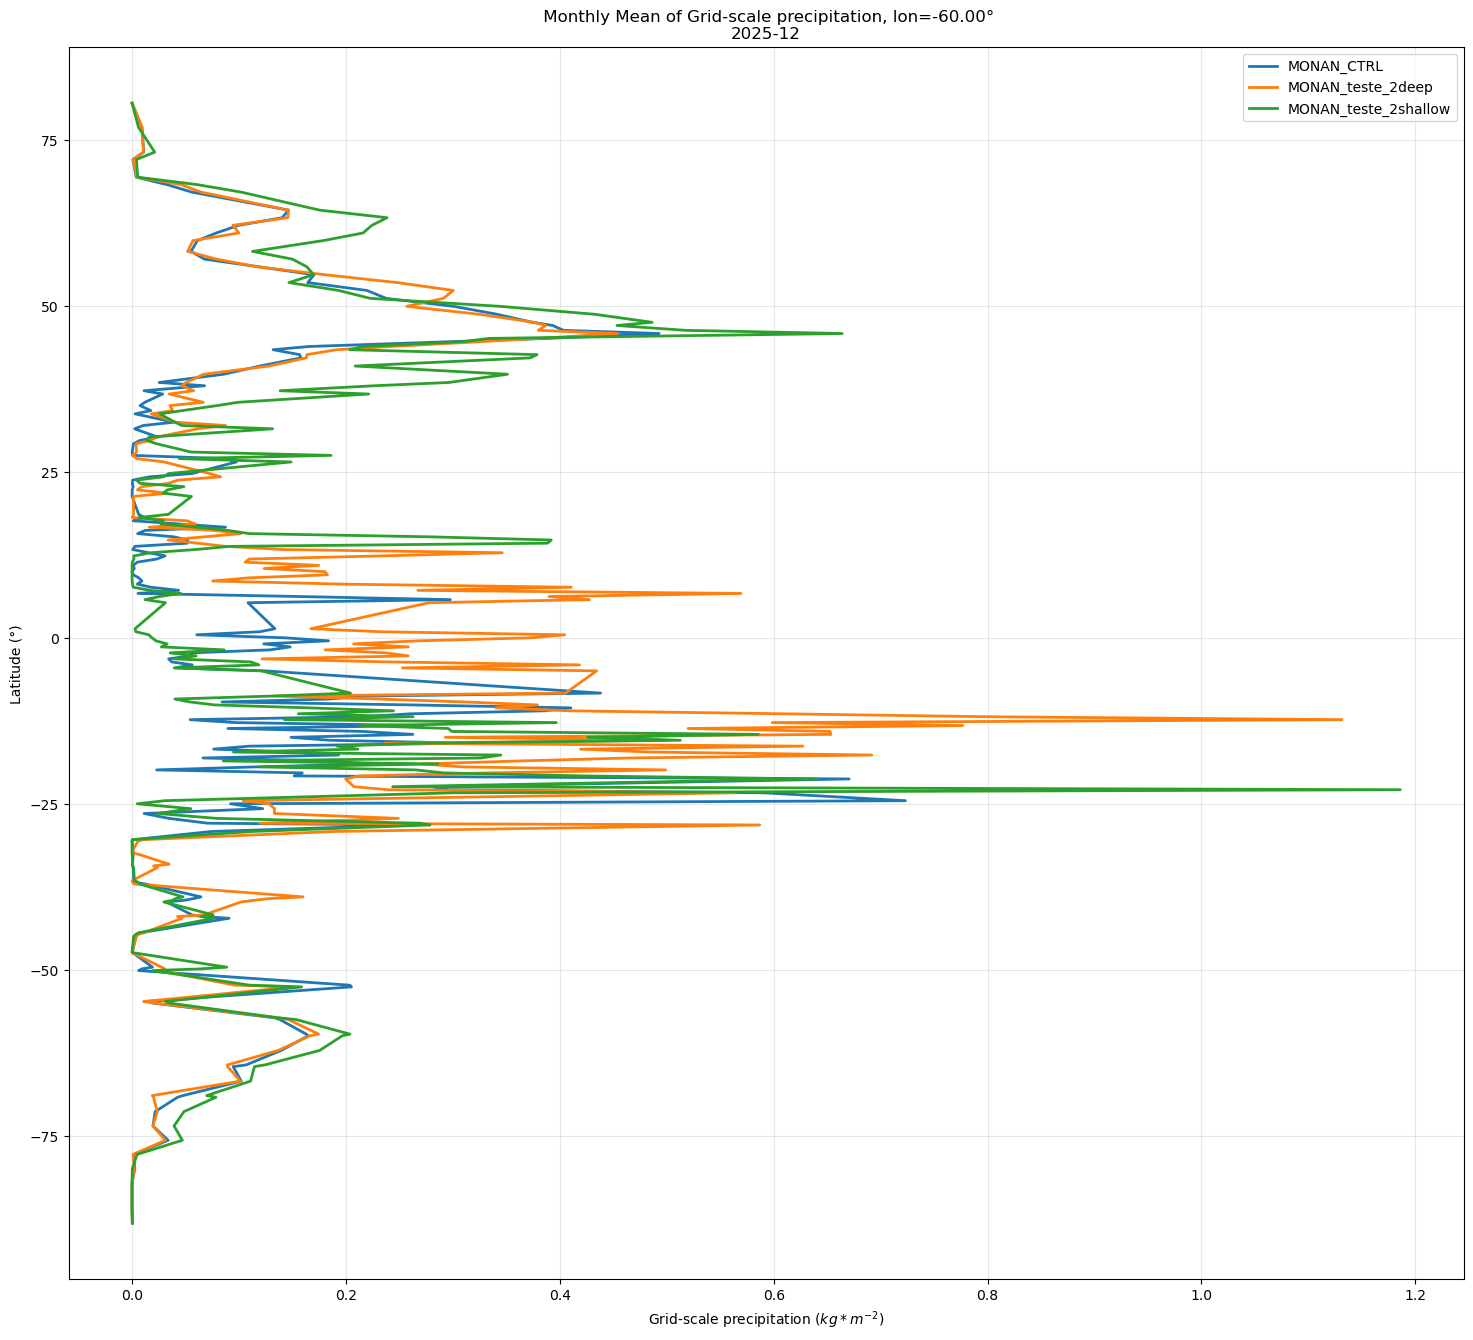

In [ ]:
plt.figure(figsize=(18, 16))
exps=[exp for exp in exps_data.keys() if exp != "teste_10deep"]
for exp_name in exps:
# for exp_name in exps_data.keys():
    print(f"Plotting latitude slice for experiment: {exp_name}" )
    monan_dir=exps_data[exp_name]["dir"]
    monan_file=f'{monan_dir}/{init}_hourly_{var_dict[var]["monan_name"]}.nc'
    monan_path = Path(monan_file)

    if os.path.exists(monan_path):
        plt.plot(exps_data[exp_name]["monan_slice_sorted_monmean"], exps_data[exp_name]["monan_lat_slice_sorted"], label=f"MONAN_{exp_name}", linewidth=2)
if os.path.exists(era5_path):
    plt.plot(era5_values, era5_lat, label=f"ERA5", linewidth=2)
# Plot CERES if available
try:
    if 'ceres_var_name' in locals() and 'ceres_values' in locals():
        plt.plot(ceres_values, ceres_lat, label=f"CERES", linewidth=2)
except:
    pass  # CERES data not available yet
plt.xlabel(f"{var_dict[var]['label']} (${var_dict[var]['unit']})$")
plt.ylabel('Latitude (°)')
plt.title(f" Monthly Mean of {var_dict[var]['label']}, lon={target_lon:.2f}°\n{year}-{month}")
plt.grid(True, alpha=0.3)
plt.legend()

# Save the plot
out_png = f"{fig_path}/{var}_{init}_24_accum_lon{int(target_lon)}_{exp_name}.png"
plt.savefig(out_png, dpi=150, bbox_inches='tight')
print(f"Saved plot to: {out_png}")
plt.show()
plt.close()

### Closing MONAN and ERA5 files

In [ ]:
for exps_data_key in exps_data.keys():
    exps_data[exps_data_key]["ds_monan"].close()
ds_era5.close()

### Closing CERES file

In [ ]:
try:
    sd.end()
except Exception:
    pass